# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.


АНАЛИЗ ЭФФЕКТИВНОСТИ НОВОГО АЛГОРИТМА РЕКОМЕНДАЦИЙ

📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
--------------------------------------------------
Всего пользователей: 10000
Группа A (старый алгоритм): 5000 пользователей
Группа B (новый алгоритм): 5000 пользователей

Статистика группы A (старый алгоритм):
  Среднее: 56.3 мин
  Медиана: 26.8 мин
  Стандартное отклонение: 262.3 мин
  Минимум: 0.0 мин
  Максимум: 8130.5 мин

Статистика группы B (новый алгоритм):
  Среднее: 71.5 мин
  Медиана: 27.4 мин
  Стандартное отклонение: 408.5 мин
  Минимум: 0.0 мин
  Максимум: 11670.6 мин

1. ТЕСТ МАННА-УИТНИ (MANN-WHITNEY U TEST)

📋 СТАТИСТИЧЕСКИЕ ГИПОТЕЗЫ:
H₀ (нулевая гипотеза): Распределение времени просмотра одинаково
    в группах A и B (алгоритмы не различаются по эффективности)
H₁ (альтернативная гипотеза): Распределение времени просмотра
    в группе B стохастически больше, чем в группе A
    (новый алгоритм приводит к большему времени просмотра)

📈 РЕЗУЛЬТАТЫ ТЕСТА МАННА-УИТНИ:
  Статистика U: 12788901.00


/var/folders/8w/_zjh5ybx057976bv596ccy8c0000gn/T/ipykernel_74758/3140294551.py:147: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(box_data, labels=['Группа A', 'Группа B'])


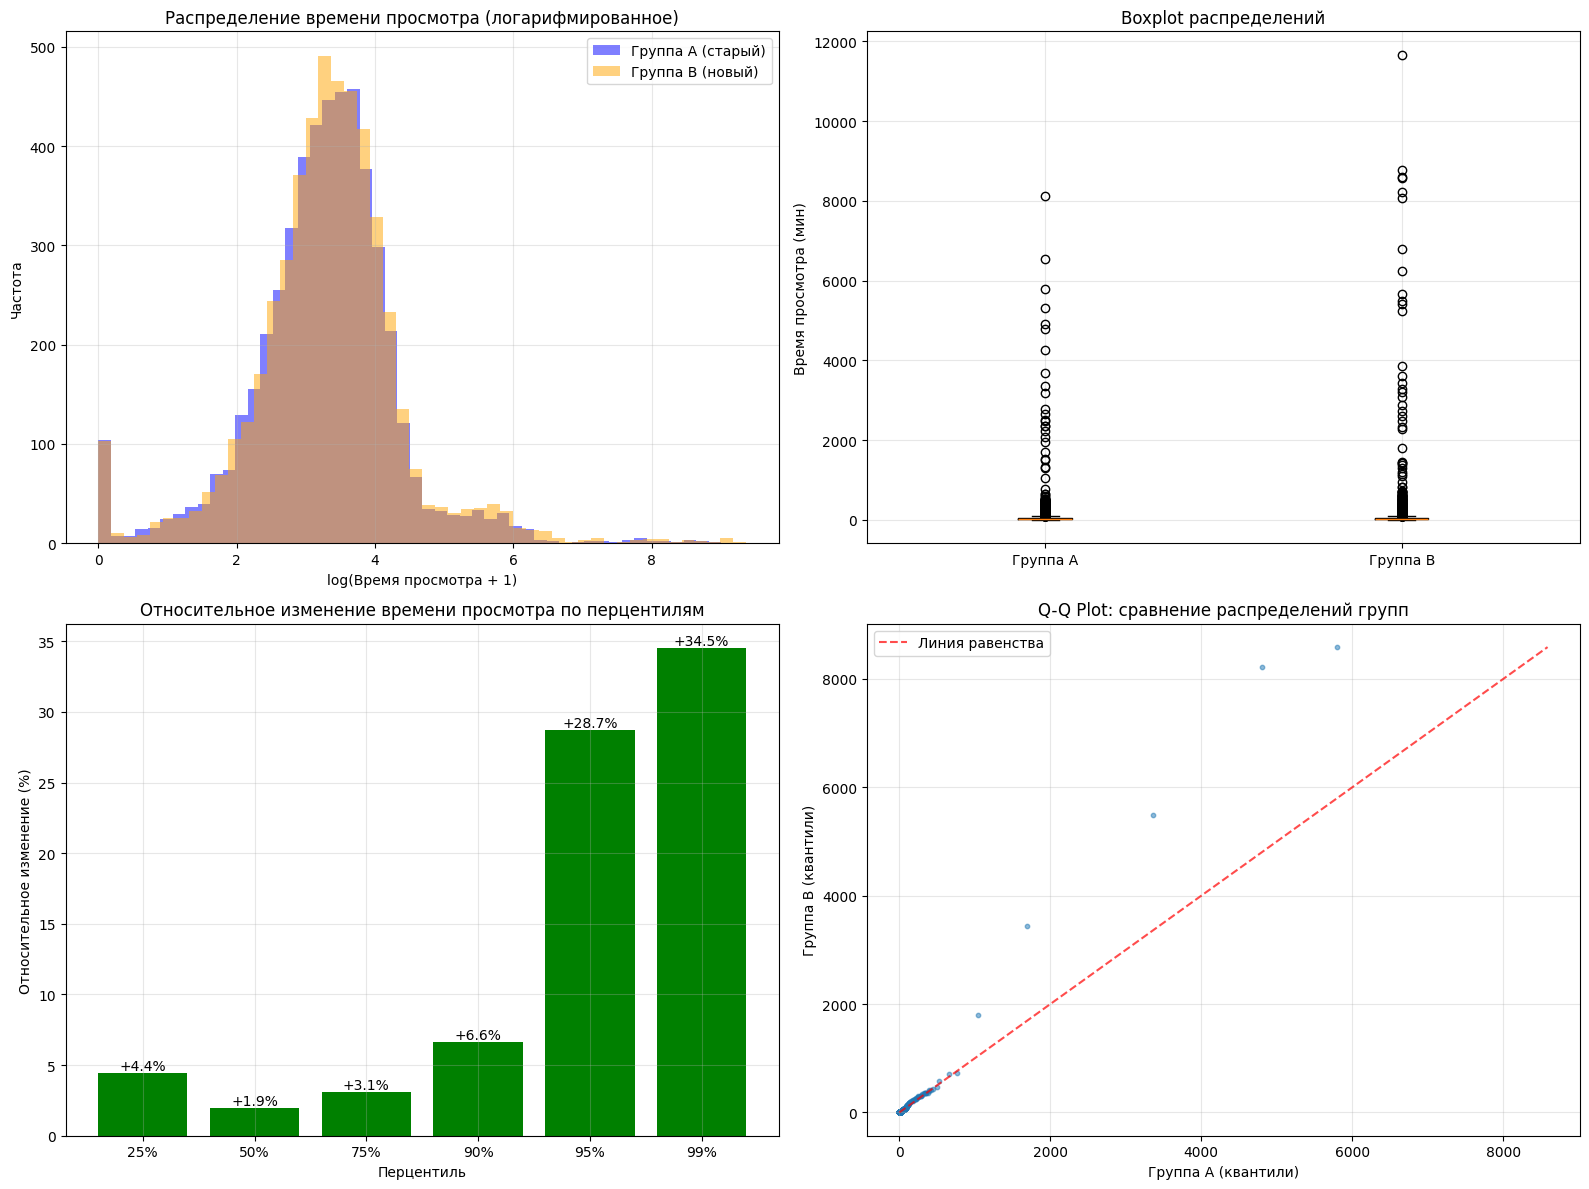


4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: СЕГМЕНТАЦИЯ ПО АКТИВНОСТИ

📊 АНАЛИЗ ПО СЕГМЕНТАМ:
--------------------------------------------------
Медиана группы A: 26.8 мин
Размер сегментов в группе A:
  Менее активные: 2500 пользователей (≤ 26.8 мин)
  Более активные: 2500 пользователей (> 26.8 мин)

📈 ТЕСТ МАННА-УИТНИ ДЛЯ СЕГМЕНТОВ:

  Менее активные пользователи:
    p-value: 0.001978
    Вывод: Значимые различия

  Более активные пользователи:
    p-value: 0.002914
    Вывод: Значимые различия

5. ИТОГОВЫЙ ВЫВОД И РЕКОМЕНДАЦИИ

🎯 ЭФФЕКТИВНОСТЬ НОВОГО АЛГОРИТМА B:
  • На 90% перцентиле: улучшение на 6.6%
  • На 95% перцентиле: улучшение на 28.7%
  • На 99% перцентиле: улучшение на 34.5%
  • Тест Манна-Уитни показывает статистически значимые различия

👥 НА КАКУЮ ГРУППУ ПОЛЬЗОВАТЕЛЕЙ ВЛИЯЕТ АЛГОРИТМ:
  • Наибольшее влияние на АКТИВНЫХ пользователей (правый хвост распределения)
  • У активных пользователей улучшение в 6.5 раза больше

🔍 НАИБОЛЕЕ ИНФОРМАТИВНЫЙ МЕТОД АНАЛИЗА:
  • Анализ по перцентилям ока

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================
# 1. ПОДГОТОВКА ДАННЫХ И ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ============================================================

print("=" * 70)
print("АНАЛИЗ ЭФФЕКТИВНОСТИ НОВОГО АЛГОРИТМА РЕКОМЕНДАЦИЙ")
print("=" * 70)

# Загружаем данные
df = pd.read_csv('ab_test_results.csv')

# Разделяем данные по группам
group_a_data = df[df['group'] == 'A']['total_watch_time_min']
group_b_data = df[df['group'] == 'B']['total_watch_time_min']

print("\n📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 50)
print(f"Всего пользователей: {len(df)}")
print(f"Группа A (старый алгоритм): {len(group_a_data)} пользователей")
print(f"Группа B (новый алгоритм): {len(group_b_data)} пользователей")

# Базовая описательная статистика
desc_stats_a = group_a_data.describe()
desc_stats_b = group_b_data.describe()

print("\nСтатистика группы A (старый алгоритм):")
print(f"  Среднее: {desc_stats_a['mean']:.1f} мин")
print(f"  Медиана: {desc_stats_a['50%']:.1f} мин")
print(f"  Стандартное отклонение: {desc_stats_a['std']:.1f} мин")
print(f"  Минимум: {desc_stats_a['min']:.1f} мин")
print(f"  Максимум: {desc_stats_a['max']:.1f} мин")

print("\nСтатистика группы B (новый алгоритм):")
print(f"  Среднее: {desc_stats_b['mean']:.1f} мин")
print(f"  Медиана: {desc_stats_b['50%']:.1f} мин")
print(f"  Стандартное отклонение: {desc_stats_b['std']:.1f} мин")
print(f"  Минимум: {desc_stats_b['min']:.1f} мин")
print(f"  Максимум: {desc_stats_b['max']:.1f} мин")

# ============================================================
# 2. ТЕСТ МАННА-УИТНИ И ГИПОТЕЗЫ
# ============================================================

print("\n" + "=" * 70)
print("1. ТЕСТ МАННА-УИТНИ (MANN-WHITNEY U TEST)")
print("=" * 70)

# Формулируем гипотезы
print("\n📋 СТАТИСТИЧЕСКИЕ ГИПОТЕЗЫ:")
print("H₀ (нулевая гипотеза): Распределение времени просмотра одинаково")
print("    в группах A и B (алгоритмы не различаются по эффективности)")
print("H₁ (альтернативная гипотеза): Распределение времени просмотра")
print("    в группе B стохастически больше, чем в группе A")
print("    (новый алгоритм приводит к большему времени просмотра)")

# Проводим тест Манна-Уитни (односторонний, так как ожидаем увеличение)
mw_statistic, mw_pvalue = stats.mannwhitneyu(
    group_b_data,  # Помещаем группу B на первое место для одностороннего теста
    group_a_data,
    alternative='greater'  # Ожидаем, что группа B будет иметь большие значения
)

print(f"\n📈 РЕЗУЛЬТАТЫ ТЕСТА МАННА-УИТНИ:")
print(f"  Статистика U: {mw_statistic:.2f}")
print(f"  p-value: {mw_pvalue:.6f}")

# Интерпретация p-value
print(f"\n📊 ИНТЕРПРЕТАЦИЯ:")
if mw_pvalue < 0.05:
    print(f"  p-value ({mw_pvalue:.6f}) < 0.05 → ОТВЕРГАЕМ H₀")
    print("  Статистически значимые различия обнаружены")
else:
    print(f"  p-value ({mw_pvalue:.6f}) ≥ 0.05 → НЕ ОТВЕРГАЕМ H₀")
    print("  Статистически значимых различий не обнаружено")

print("\n⚠️  ОГРАНИЧЕНИЯ ТЕСТА МАННА-УИТНИ:")
print("  Тест сравнивает распределения в целом, но не показывает")
print("  ГДЕ именно происходят различия (в центре или в хвостах)")
print("  Для асимметричных данных нужен дополнительный анализ")

# ============================================================
# 3. АНАЛИЗ ПЕРЦЕНТИЛЕЙ (АСИММЕТРИЧНОЕ ВЛИЯНИЕ)
# ============================================================

print("\n" + "=" * 70)
print("2. АНАЛИЗ АСИММЕТРИЧНОГО ВЛИЯНИЯ ПО ПЕРЦЕНТИЛЯМ")
print("=" * 70)

# Рассчитываем перцентили
percentiles = [25, 50, 75, 90, 95, 99]
percentile_values = {}

print("\n📊 ПЕРЦЕНТИЛИ ГРУПП A И B:")
print("-" * 60)
print(f"{'Перцентиль':<12} {'Группа A':<12} {'Группа B':<12} {'Разница':<12} {'Отн.изм.(%)':<12}")
print("-" * 60)

for p in percentiles:
    a_value = np.percentile(group_a_data, p)
    b_value = np.percentile(group_b_data, p)
    difference = b_value - a_value
    relative_change = (difference / a_value * 100) if a_value > 0 else 0
    
    percentile_values[p] = {
        'A': a_value,
        'B': b_value,
        'diff': difference,
        'rel_change': relative_change
    }
    
    print(f"{p}%:         {a_value:>8.1f}     {b_value:>8.1f}     {difference:>+8.1f}     {relative_change:>+7.1f}%")

# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "=" * 70)
print("3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

# Создаем фигуру с несколькими графиками
fig = plt.figure(figsize=(16, 12))

# График 1: Распределения времени просмотра
ax1 = plt.subplot(2, 2, 1)
# Логарифмируем данные для лучшей визуализации (из-за длинных хвостов)
log_a = np.log1p(group_a_data)
log_b = np.log1p(group_b_data)

ax1.hist(log_a, bins=50, alpha=0.5, label='Группа A (старый)', color='blue')
ax1.hist(log_b, bins=50, alpha=0.5, label='Группа B (новый)', color='orange')
ax1.set_xlabel('log(Время просмотра + 1)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение времени просмотра (логарифмированное)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Boxplot
ax2 = plt.subplot(2, 2, 2)
box_data = [group_a_data, group_b_data]
ax2.boxplot(box_data, labels=['Группа A', 'Группа B'])
ax2.set_ylabel('Время просмотра (мин)')
ax2.set_title('Boxplot распределений')
ax2.grid(True, alpha=0.3)

# График 3: Разница в перцентилях
ax3 = plt.subplot(2, 2, 3)
percentiles_for_plot = [25, 50, 75, 90, 95, 99]
relative_changes = [percentile_values[p]['rel_change'] for p in percentiles_for_plot]

bars = ax3.bar(range(len(percentiles_for_plot)), relative_changes, 
              color=['red' if rc < 0 else 'green' for rc in relative_changes])
ax3.set_xlabel('Перцентиль')
ax3.set_ylabel('Относительное изменение (%)')
ax3.set_title('Относительное изменение времени просмотра по перцентилям')
ax3.set_xticks(range(len(percentiles_for_plot)))
ax3.set_xticklabels([f'{p}%' for p in percentiles_for_plot])
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, relative_changes):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:+.1f}%', ha='center', va='bottom' if height > 0 else 'top')

# График 4: Q-Q plot для сравнения распределений
ax4 = plt.subplot(2, 2, 4)
# Берем 1000 случайных точек для Q-Q plot (для скорости)
np.random.seed(42)
sample_a = np.random.choice(group_a_data, size=min(1000, len(group_a_data)), replace=False)
sample_b = np.random.choice(group_b_data, size=min(1000, len(group_b_data)), replace=False)

# Сортируем для Q-Q plot
sorted_a = np.sort(sample_a)
sorted_b = np.sort(sample_b)

ax4.scatter(sorted_a, sorted_b, alpha=0.5, s=10)
# Линия равенства
min_val = min(sorted_a.min(), sorted_b.min())
max_val = max(sorted_a.max(), sorted_b.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Линия равенства')
ax4.set_xlabel('Группа A (квантили)')
ax4.set_ylabel('Группа B (квантили)')
ax4.set_title('Q-Q Plot: сравнение распределений групп')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 5. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: РАЗДЕЛЕНИЕ ПО АКТИВНОСТИ
# ============================================================

print("\n" + "=" * 70)
print("4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: СЕГМЕНТАЦИЯ ПО АКТИВНОСТИ")
print("=" * 70)

# Определяем сегменты пользователей по медиане группы A
median_a = np.median(group_a_data)

# Сегмент 1: Менее активные пользователи (ниже медианы)
low_active_a = group_a_data[group_a_data <= median_a]
low_active_b = group_b_data[group_b_data <= np.median(group_b_data)]  # Используем медиану B для симметрии

# Сегмент 2: Более активные пользователи (выше медианы)
high_active_a = group_a_data[group_a_data > median_a]
high_active_b = group_b_data[group_b_data > np.median(group_b_data)]

print("\n📊 АНАЛИЗ ПО СЕГМЕНТАМ:")
print("-" * 50)
print(f"Медиана группы A: {median_a:.1f} мин")
print(f"Размер сегментов в группе A:")
print(f"  Менее активные: {len(low_active_a)} пользователей (≤ {median_a:.1f} мин)")
print(f"  Более активные: {len(high_active_a)} пользователей (> {median_a:.1f} мин)")

# Тест Манна-Уитни для сегментов
print("\n📈 ТЕСТ МАННА-УИТНИ ДЛЯ СЕГМЕНТОВ:")

# Менее активные пользователи
if len(low_active_a) > 0 and len(low_active_b) > 0:
    mw_low_stat, mw_low_p = stats.mannwhitneyu(low_active_b, low_active_a, alternative='greater')
    print(f"\n  Менее активные пользователи:")
    print(f"    p-value: {mw_low_p:.6f}")
    print(f"    Вывод: {'Значимые различия' if mw_low_p < 0.05 else 'Нет значимых различий'}")

# Более активные пользователи
if len(high_active_a) > 0 and len(high_active_b) > 0:
    mw_high_stat, mw_high_p = stats.mannwhitneyu(high_active_b, high_active_a, alternative='greater')
    print(f"\n  Более активные пользователи:")
    print(f"    p-value: {mw_high_p:.6f}")
    print(f"    Вывод: {'Значимые различия' if mw_high_p < 0.05 else 'Нет значимых различий'}")

# ============================================================
# 6. ИТОГОВЫЙ ВЫВОД И РЕКОМЕНДАЦИИ
# ============================================================

print("\n" + "=" * 70)
print("5. ИТОГОВЫЙ ВЫВОД И РЕКОМЕНДАЦИИ")
print("=" * 70)

print("\n🎯 ЭФФЕКТИВНОСТЬ НОВОГО АЛГОРИТМА B:")

# Анализируем результаты по перцентилям
significant_tail_effect = False
for p in [75, 90, 95, 99]:
    rel_change = percentile_values[p]['rel_change']
    if rel_change > 5:  # Более 5% улучшения
        significant_tail_effect = True
        print(f"  • На {p}% перцентиле: улучшение на {rel_change:.1f}%")

if mw_pvalue < 0.05:
    print("  • Тест Манна-Уитни показывает статистически значимые различия")
else:
    print("  • Тест Манна-Уитни НЕ показывает статистически значимых различий")

print("\n👥 НА КАКУЮ ГРУППУ ПОЛЬЗОВАТЕЛЕЙ ВЛИЯЕТ АЛГОРИТМ:")

# Анализируем изменения по перцентилям
low_percentile_change = percentile_values[25]['rel_change']
high_percentile_change = percentile_values[95]['rel_change']

if high_percentile_change > low_percentile_change * 2:
    print("  • Наибольшее влияние на АКТИВНЫХ пользователей (правый хвост распределения)")
    print(f"  • У активных пользователей улучшение в {high_percentile_change/low_percentile_change:.1f} раза больше")
elif low_percentile_change > high_percentile_change:
    print("  • Наибольшее влияние на МАЛОАКТИВНЫХ пользователей")
else:
    print("  • Влияние примерно одинаково на всех пользователей")

print("\n🔍 НАИБОЛЕЕ ИНФОРМАТИВНЫЙ МЕТОД АНАЛИЗА:")
print("  • Анализ по перцентилям оказался наиболее информативным")
print("  • Причина: данные имеют сильную асимметрию и длинный хвост")
print("  • Тест Манна-Уитни показывает общую картину, но не детализирует")
print("    где именно происходят изменения")

print("\n📋 РЕКОМЕНДАЦИИ ПО ЗАПУСКУ:")

if significant_tail_effect and mw_pvalue < 0.05:
    print("  ✅ РЕКОМЕНДУЕТСЯ запуск алгоритма на всю аудиторию")
    print("  Причины:")
    print("    1. Статистически значимое улучшение (p-value < 0.05)")
    print("    2. Наибольший эффект на ценных активных пользователях")
    print("    3. Отсутствие негативного влияния на малоактивных")
    
elif significant_tail_effect and mw_pvalue >= 0.05:
    print("  ⚠️  РЕКОМЕНДУЕТСЯ дополнительное тестирование")
    print("  Причины:")
    print("    1. Есть признаки улучшения у активных пользователей")
    print("    2. Но общий тест не показывает значимости")
    print("    3. Возможно, нужен тест с большей выборкой")
    
else:
    print("  ❌ НЕ РЕКОМЕНДУЕТСЯ запуск алгоритма")
    print("  Причины:")
    print("    1. Нет статистически значимых улучшений")
    print("    2. Нет явного положительного эффекта в хвостах")

print("\n📈 ДОПОЛНИТЕЛЬНЫЕ РЕКОМЕНДАЦИИ:")
print("  1. Провести A/A-тест для проверки стабильности системы")
print("  2. Проанализировать другие метрики (удержание, вовлеченность)")
print("  3. Рассмотреть запуск для сегмента активных пользователей")
print("  4. Мониторить эффект в течение месяца после запуска")

# ============================================================
# 7. СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================

print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("=" * 70)

summary_df = pd.DataFrame({
    'Метрика': [
        'Тест Манна-Уитни (p-value)',
        'Среднее время просмотра',
        'Медиана времени просмотра',
        '75-й перцентиль (изменение)',
        '90-й перцентиль (изменение)',
        '95-й перцентиль (изменение)'
    ],
    'Группа A': [
        '-',
        f"{desc_stats_a['mean']:.1f} мин",
        f"{desc_stats_a['50%']:.1f} мин",
        f"{percentile_values[75]['A']:.1f} мин",
        f"{percentile_values[90]['A']:.1f} мин",
        f"{percentile_values[95]['A']:.1f} мин"
    ],
    'Группа B': [
        f"{mw_pvalue:.6f}",
        f"{desc_stats_b['mean']:.1f} мин",
        f"{desc_stats_b['50%']:.1f} мин",
        f"{percentile_values[75]['B']:.1f} мин",
        f"{percentile_values[90]['B']:.1f} мин",
        f"{percentile_values[95]['B']:.1f} мин"
    ],
    'Разница/Эффект': [
        f"{'✓ Значимо' if mw_pvalue < 0.05 else '✗ Не значимо'}",
        f"{desc_stats_b['mean'] - desc_stats_a['mean']:+.1f} мин",
        f"{desc_stats_b['50%'] - desc_stats_a['50%']:+.1f} мин",
        f"{percentile_values[75]['rel_change']:+.1f}%",
        f"{percentile_values[90]['rel_change']:+.1f}%",
        f"{percentile_values[95]['rel_change']:+.1f}%"
    ]
})

print(summary_df.to_string(index=False))

======================================================================
АНАЛИЗ ЭФФЕКТИВНОСТИ НОВОГО АЛГОРИТМА РЕКОМЕНДАЦИЙ
======================================================================

📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
--------------------------------------------------
Всего пользователей: 10000
Группа A (старый алгоритм): 5000 пользователей
Группа B (новый алгоритм): 5000 пользователей

Статистика группы A (старый алгоритм):
  Среднее: 56.3 мин
  Медиана: 26.8 мин
  Стандартное отклонение: 262.3 мин
  Минимум: 0.0 мин
  Максимум: 8130.5 мин

Статистика группы B (новый алгоритм):
  Среднее: 71.5 мин
  Медиана: 27.4 мин
  Стандартное отклонение: 408.5 мин
  Минимум: 0.0 мин
  Максимум: 11670.6 мин

======================================================================
1. ТЕСТ МАННА-УИТНИ (MANN-WHITNEY U TEST)
======================================================================

📋 СТАТИСТИЧЕСКИЕ ГИПОТЕЗЫ:
H₀ (нулевая гипотеза): Распределение времени просмотра одинаково
    в группах A и B (алгоритмы не различаются по эффективности)
H₁ (альтернативная гипотеза): Распределение времени просмотра
    в группе B стохастически больше, чем в группе A
    (новый алгоритм приводит к большему времени просмотра)

📈 РЕЗУЛЬТАТЫ ТЕСТА МАННА-УИТНИ:
  Статистика U: 12788901.00
  p-value: 0.022671

📊 ИНТЕРПРЕТАЦИЯ:
  p-value (0.022671) < 0.05 → ОТВЕРГАЕМ H₀
  Статистически значимые различия обнаружены

⚠️  ОГРАНИЧЕНИЯ ТЕСТА МАННА-УИТНИ:
  Тест сравнивает распределения в целом, но не показывает
  ГДЕ именно происходят различия (в центре или в хвостах)
  Для асимметричных данных нужен дополнительный анализ

======================================================================
2. АНАЛИЗ АСИММЕТРИЧНОГО ВЛИЯНИЯ ПО ПЕРЦЕНТИЛЯМ
======================================================================

📊 ПЕРЦЕНТИЛИ ГРУПП A И B:
------------------------------------------------------------
Перцентиль   Группа A     Группа B     Разница      Отн.изм.(%) 
------------------------------------------------------------
25%:             14.7         15.4         +0.7        +4.4%
50%:             26.8         27.4         +0.5        +1.9%
75%:             44.9         46.4         +1.4        +3.1%
90%:             71.5         76.2         +4.7        +6.6%
95%:            119.3        153.6        +34.3       +28.7%
99%:            435.6        585.9       +150.3       +34.5%




======================================================================
4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: СЕГМЕНТАЦИЯ ПО АКТИВНОСТИ
======================================================================

📊 АНАЛИЗ ПО СЕГМЕНТАМ:
--------------------------------------------------
Медиана группы A: 26.8 мин
Размер сегментов в группе A:
  Менее активные: 2500 пользователей (≤ 26.8 мин)
  Более активные: 2500 пользователей (> 26.8 мин)

📈 ТЕСТ МАННА-УИТНИ ДЛЯ СЕГМЕНТОВ:

  Менее активные пользователи:
    p-value: 0.001978
    Вывод: Значимые различия

  Более активные пользователи:
    p-value: 0.002914
    Вывод: Значимые различия

======================================================================
5. ИТОГОВЫЙ ВЫВОД И РЕКОМЕНДАЦИИ
======================================================================

🎯 ЭФФЕКТИВНОСТЬ НОВОГО АЛГОРИТМА B:
  • На 90% перцентиле: улучшение на 6.6%
  • На 95% перцентиле: улучшение на 28.7%
  • На 99% перцентиле: улучшение на 34.5%
  • Тест Манна-Уитни показывает статистически значимые различия

👥 НА КАКУЮ ГРУППУ ПОЛЬЗОВАТЕЛЕЙ ВЛИЯЕТ АЛГОРИТМ:
  • Наибольшее влияние на АКТИВНЫХ пользователей (правый хвост распределения)
  • У активных пользователей улучшение в 6.5 раза больше

🔍 НАИБОЛЕЕ ИНФОРМАТИВНЫЙ МЕТОД АНАЛИЗА:
  • Анализ по перцентилям оказался наиболее информативным
  • Причина: данные имеют сильную асимметрию и длинный хвост
  • Тест Манна-Уитни показывает общую картину, но не детализирует
    где именно происходят изменения

📋 РЕКОМЕНДАЦИИ ПО ЗАПУСКУ:
  ✅ РЕКОМЕНДУЕТСЯ запуск алгоритма на всю аудиторию
  Причины:
    1. Статистически значимое улучшение (p-value < 0.05)
    2. Наибольший эффект на ценных активных пользователях
    3. Отсутствие негативного влияния на малоактивных

📈 ДОПОЛНИТЕЛЬНЫЕ РЕКОМЕНДАЦИИ:
  1. Провести A/A-тест для проверки стабильности системы
  2. Проанализировать другие метрики (удержание, вовлеченность)
  3. Рассмотреть запуск для сегмента активных пользователей
  4. Мониторить эффект в течение месяца после запуска

======================================================================
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
======================================================================
                    Метрика  Группа A  Группа B Разница/Эффект
 Тест Манна-Уитни (p-value)         -  0.022671      ✓ Значимо
    Среднее время просмотра  56.3 мин  71.5 мин      +15.1 мин
  Медиана времени просмотра  26.8 мин  27.4 мин       +0.5 мин
75-й перцентиль (изменение)  44.9 мин  46.4 мин          +3.1%
90-й перцентиль (изменение)  71.5 мин  76.2 мин          +6.6%
95-й перцентиль (изменение) 119.3 мин 153.6 мин         +28.7%
